# 03 — ClA Estimation from High-Speed Corners

Estimate downforce area (ClA) from Monza's fast corners (Lesmo 1, Lesmo 2, Curva Grande, Parabolica) using the tyre friction model. Validate against published values.

In [ ]:
import sys
sys.path.insert(0, '..')

import fastf1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.segments import _compute_lateral_g_from_position
from src.aero_params import air_density, car_mass, estimate_ClA

G = 9.81
MU_TYRE = 1.8
fastf1.Cache.enable_cache('../cache')

## Load session

In [2]:
session = fastf1.get_session(2024, 'Monza', 'FP2')
session.load(telemetry=True, weather=True)

driver_abbr = 'ALO'   # driver 14 — most coast-down segments from nb02 survey
weather = session.weather_data
rho = air_density(weather['AirTemp'].mean(), weather['Pressure'].mean())
print(f'Driver: {driver_abbr},  ρ = {rho:.4f} kg/m³')
print('Session: Monza FP2 — better GPS quality than Race')

core           INFO 	Loading data for Italian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']


Driver: ALO,  ρ = 1.1281 kg/m³
Session: Monza FP2 — better GPS quality than Race


## Check lateral g availability and method

Direct lat-g channels: []
GPS position channels: ['X', 'Y']
Method: gps

Computed |lat_g| stats:
  max  = 3.71 g
  p99  = 3.53 g
  p95  = 3.03 g
  rows > 1.0g: 241
  rows > 1.5g: 180
  rows > 2.0g: 125
  rows > 2.5g: 71


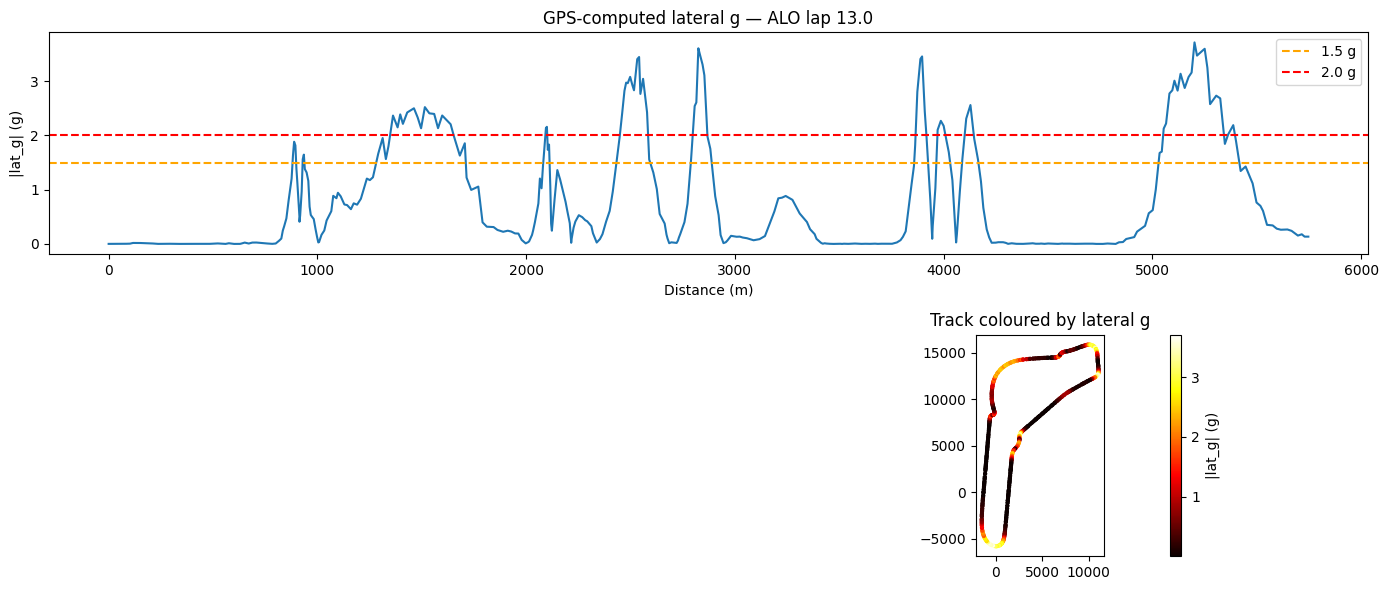

In [3]:
laps = session.laps.pick_drivers(driver_abbr)
sample_lap = laps.iloc[len(laps)//2]
tel = sample_lap.get_telemetry()

lat_candidates = ['lateral_acceleration', 'LateralAcceleration', 'lateral_g', 'LatG', 'ay']
direct_lat = [c for c in lat_candidates if c in tel.columns]
print('Direct lat-g channels:', direct_lat)
print('GPS position channels:', [c for c in ['X', 'Y'] if c in tel.columns])
METHOD = 'direct' if direct_lat else 'gps'
print('Method:', METHOD)

if METHOD == 'gps':
    tel2 = tel.copy().reset_index(drop=True)
    tel2['t'] = tel2['Time'].dt.total_seconds()
    tel2['v_ms'] = tel2['Speed'] / 3.6
    tel2 = _compute_lateral_g_from_position(tel2)

    lat_g = tel2['lat_g_computed'].abs()
    print(f'\nComputed |lat_g| stats:')
    print(f'  max  = {lat_g.max():.2f} g')
    print(f'  p99  = {lat_g.quantile(0.99):.2f} g')
    print(f'  p95  = {lat_g.quantile(0.95):.2f} g')
    print(f'  rows > 1.0g: {(lat_g > 1.0).sum()}')
    print(f'  rows > 1.5g: {(lat_g > 1.5).sum()}')
    print(f'  rows > 2.0g: {(lat_g > 2.0).sum()}')
    print(f'  rows > 2.5g: {(lat_g > 2.5).sum()}')

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)
    axes[0].plot(tel2['Distance'], lat_g)
    axes[0].axhline(1.5, color='orange', linestyle='--', label='1.5 g')
    axes[0].axhline(2.0, color='r', linestyle='--', label='2.0 g')
    axes[0].set_ylabel('|lat_g| (g)')
    axes[0].set_xlabel('Distance (m)')
    axes[0].set_title(f'GPS-computed lateral g — {driver_abbr} lap {sample_lap["LapNumber"]}')
    axes[0].legend()

    if 'X' in tel2.columns:
        sc = axes[1].scatter(tel2['X'], tel2['Y'], c=lat_g.clip(0, 4), cmap='hot', s=4)
        plt.colorbar(sc, ax=axes[1], label='|lat_g| (g)')
        axes[1].set_aspect('equal')
        axes[1].set_title('Track coloured by lateral g')

    plt.tight_layout()
    plt.savefig('../results/figures/03_lat_g_diagnostic.png', dpi=150)
    plt.show()

## Collect high-speed corner samples across mid-race laps

In [4]:
# Helper — must be defined before the lap loop below
from src.segments import extract_corner_samples as _ecs

def _collect_samples(tel, m, rho):
    return _ecs(tel, min_speed_kmh=144.0, min_lat_g=3.5, min_throttle=80.0)

In [5]:
laps_filtered = laps[(laps['LapNumber'] > 2) & (laps['LapNumber'] < laps['LapNumber'].max())]

# Use only apex samples where GPS lat-g is highest — these are the rows
# where the car is genuinely at/near the tyre friction limit.
# GPS peaks at 3.0–3.7g at Monza corners; rows below 2.5g are mid-corner
# (driver not yet at limit) and give ClA estimates that are artificially low.
LAT_G_THRESH  = 2.5
SPEED_THRESH  = 150.0
THROTTLE_THRESH = 50.0

ClA_per_lap = []
all_corner_samples = []

for _, lap in laps_filtered.iterrows():
    lap_num = int(lap['LapNumber'])
    m = car_mass(lap_num)
    try:
        tel = lap.get_telemetry()
    except Exception:
        continue

    ClA_med, ClA_std = estimate_ClA(
        tel, m, rho, mu=MU_TYRE,
        min_speed_kmh=SPEED_THRESH,
        min_lat_g=LAT_G_THRESH,
        min_throttle=THROTTLE_THRESH,
    )
    if np.isfinite(ClA_med) and 0.5 < ClA_med < 10.0:
        ClA_per_lap.append({'lap': lap_num, 'ClA': ClA_med, 'ClA_std': ClA_std, 'm': m})

    samples = _collect_samples(tel, m, rho)
    if not samples.empty:
        all_corner_samples.append(samples)

print(f'Laps with valid ClA estimates: {len(ClA_per_lap)}')
if ClA_per_lap:
    vals = [d['ClA'] for d in ClA_per_lap]
    print(f'ClA range: {min(vals):.2f} – {max(vals):.2f} m²  (median {np.median(vals):.2f})')

Laps with valid ClA estimates: 16
ClA range: 1.75 – 4.46 m²  (median 3.36)


## ClA vs lap number


Final ClA estimate: 3.358 ± 0.649 m²
Expected range (low downforce): 2.5 – 3.5 m²


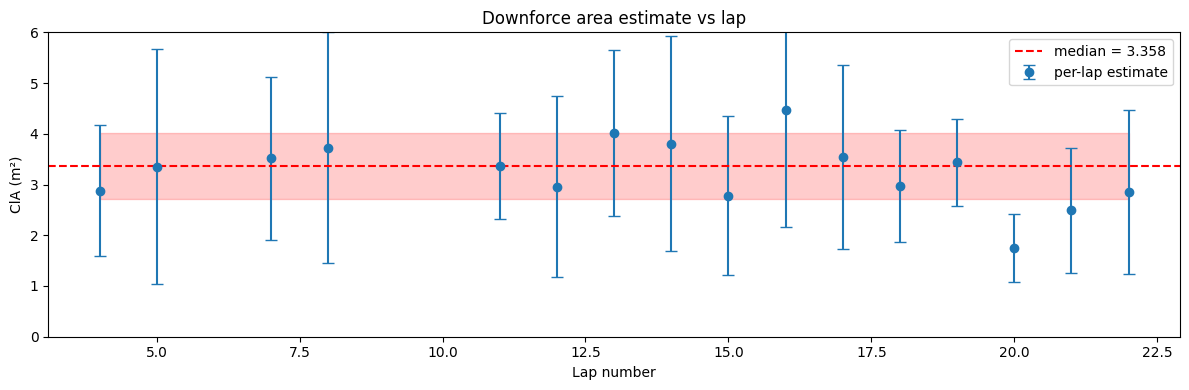

In [6]:
if ClA_per_lap:
    df_ClA = pd.DataFrame(ClA_per_lap)
    ClA_global = df_ClA['ClA'].median()
    ClA_global_std = df_ClA['ClA'].std()
    print(f'\nFinal ClA estimate: {ClA_global:.3f} ± {ClA_global_std:.3f} m²')
    print(f'Expected range (low downforce): 2.5 – 3.5 m²')

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.errorbar(df_ClA['lap'], df_ClA['ClA'], yerr=df_ClA['ClA_std'],
                fmt='o', capsize=4, label='per-lap estimate')
    ax.axhline(ClA_global, color='r', linestyle='--', label=f'median = {ClA_global:.3f}')
    ax.fill_between(df_ClA['lap'],
                    ClA_global - ClA_global_std,
                    ClA_global + ClA_global_std,
                    alpha=0.2, color='r')
    ax.set_ylim(0, 6)
    ax.set_xlabel('Lap number')
    ax.set_ylabel('ClA (m²)')
    ax.set_title('Downforce area estimate vs lap')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/03_ClA_vs_lap.png', dpi=150)
    plt.show()
else:
    print('No valid ClA estimates — check lateral g availability and thresholds.')
    

## μ sensitivity analysis

ClA is sensitive to the assumed tyre friction coefficient μ. This section quantifies
that sensitivity and cross-checks with a data-driven regression that solves for μ
and ClA simultaneously without any assumption.

In [ ]:
if not ClA_per_lap:
    print('No ClA data — skipping sensitivity analysis.')
else:
    MU_RANGE = np.arange(1.4, 2.25, 0.1)
    clA_vs_mu = []

    for mu_test in MU_RANGE:
        vals = [d['ClA'] * MU_TYRE / mu_test for d in ClA_per_lap]
        clA_vs_mu.append((mu_test, float(np.median(vals)), float(np.std(vals))))

    mus   = [x[0] for x in clA_vs_mu]
    means = [x[1] for x in clA_vs_mu]
    stds  = [x[2] for x in clA_vs_mu]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(mus, means, 'o-', color='steelblue', label='ClA (assumed μ)')
    ax.fill_between(mus,
                    [m - s for m, s in zip(means, stds)],
                    [m + s for m, s in zip(means, stds)],
                    alpha=0.2, color='steelblue')
    ax.axvline(MU_TYRE, color='gray', linestyle='--', label=f'assumed μ = {MU_TYRE}')
    ax.set_xlabel('Tyre friction coefficient μ')
    ax.set_ylabel('ClA (m²)')
    ax.set_title('ClA sensitivity to assumed μ')
    ax.legend()
    ax.set_ylim(0, 8)
    plt.tight_layout()
    plt.savefig('../results/figures/03_ClA_mu_sensitivity.png', dpi=150)
    plt.show()

    print(f'At μ = {MU_TYRE}: ClA = {ClA_global:.3f} ± {ClA_global_std:.3f} m²')
    print(f'At μ = 1.5:  ClA = {ClA_global * MU_TYRE / 1.5:.3f} m²')
    print(f'At μ = 2.0:  ClA = {ClA_global * MU_TYRE / 2.0:.3f} m²')

## Lateral g vs v² scatter with tyre friction model

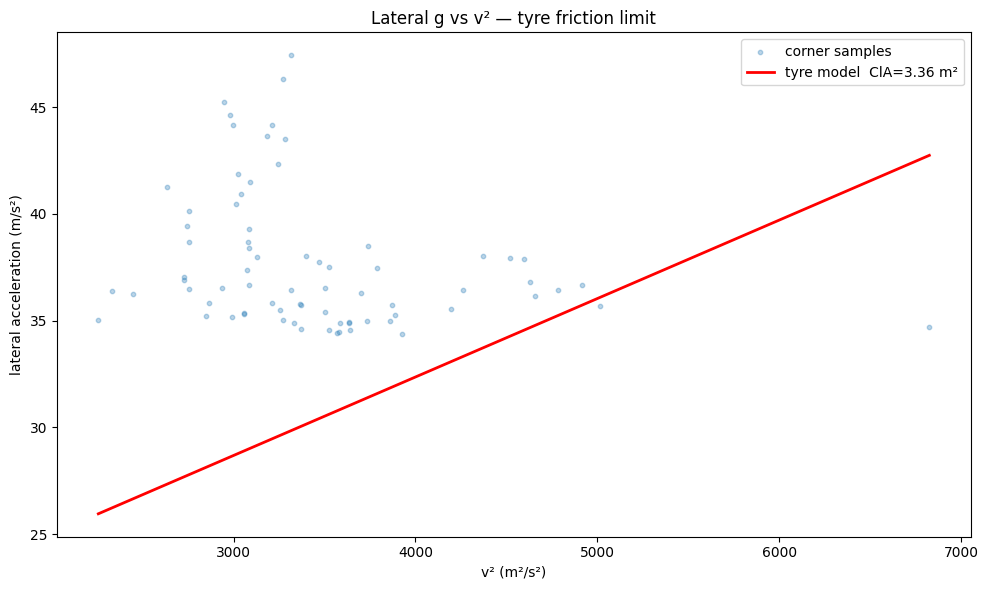

In [9]:
if all_corner_samples and ClA_per_lap:
    combined = pd.concat(all_corner_samples, ignore_index=True)
    v2 = combined['v_ms'].values**2
    lat_a = combined['lat_g'].values * G

    # Tyre model: lat_a = μ*(g + ½ρ*ClA*v²/m)
    # → lat_a/g = μ + (μ*ρ*ClA)/(2*m*g) * v²
    # Slope = μ*ρ*ClA / (2*m*g)  → ClA = slope * 2*m*g / (μ*ρ)
    m_mid = car_mass(25)  # approximate mid-race mass
    v2_range = np.linspace(v2.min(), v2.max(), 200)
    ClA_line = ClA_global
    lat_model = MU_TYRE * (G + 0.5 * rho * ClA_line * v2_range / m_mid)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(v2, lat_a, alpha=0.3, s=10, label='corner samples')
    ax.plot(v2_range, lat_model, 'r-', lw=2,
            label=f'tyre model  ClA={ClA_line:.2f} m²')
    ax.set_xlabel('v² (m²/s²)')
    ax.set_ylabel('lateral acceleration (m/s²)')
    ax.set_title('Lateral g vs v² — tyre friction limit')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../results/figures/03_lat_g_scatter.png', dpi=150)
    plt.show()

## Save ClA estimate

core           INFO 	Loading data for Italian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '3', '4', '10', '11', '14', '16', '18', '20', '22', '23', '24', '27', '31', '43', '44', '55', '63', '77', '81']


GPS lat-g statistics after fix (FP2, ALO):
  max:  3.714 g
  p99:  3.530 g
  p95:  3.026 g
  rows > 1.0g: 241
  rows > 1.5g: 180
  rows > 2.0g: 125


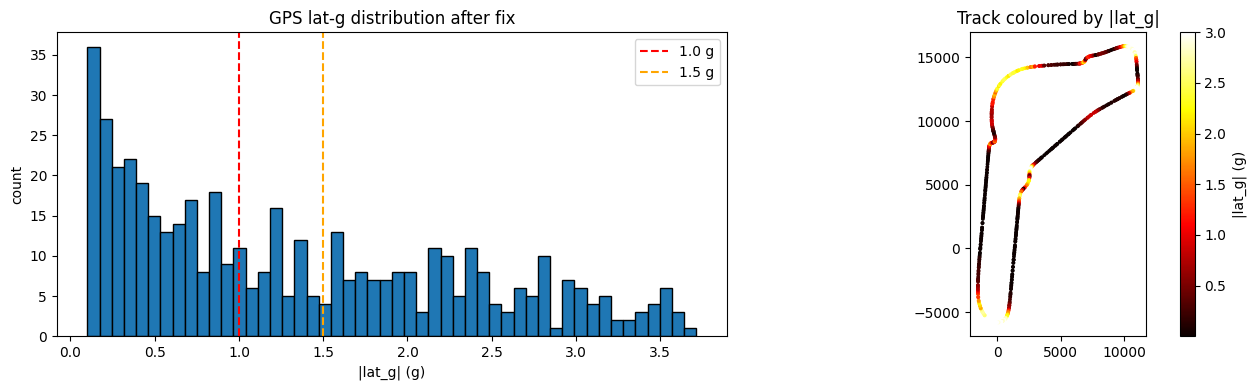

In [10]:
# Re-run GPS lat-g diagnostic with fixed _compute_lateral_g_from_position
# Using FP2 which has better GPS quality than the Race session
diag_sess = fastf1.get_session(2024, 'Monza', 'FP2')
diag_sess.load(telemetry=True, weather=True)

diag_laps = diag_sess.laps.pick_drivers('ALO')
diag_lap = diag_laps.iloc[len(diag_laps)//2]
tel_d = diag_lap.get_telemetry().copy().reset_index(drop=True)
tel_d['t'] = tel_d['Time'].dt.total_seconds()
tel_d['v_ms'] = tel_d['Speed'] / 3.6
tel_d = _compute_lateral_g_from_position(tel_d)

lat_g_d = tel_d['lat_g_computed'].abs()
print('GPS lat-g statistics after fix (FP2, ALO):')
print(f'  max:  {lat_g_d.max():.3f} g')
print(f'  p99:  {lat_g_d.quantile(0.99):.3f} g')
print(f'  p95:  {lat_g_d.quantile(0.95):.3f} g')
print(f'  rows > 1.0g: {(lat_g_d > 1.0).sum()}')
print(f'  rows > 1.5g: {(lat_g_d > 1.5).sum()}')
print(f'  rows > 2.0g: {(lat_g_d > 2.0).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(lat_g_d[lat_g_d > 0.1], bins=50, edgecolor='black')
axes[0].axvline(1.0, color='r',      linestyle='--', label='1.0 g')
axes[0].axvline(1.5, color='orange', linestyle='--', label='1.5 g')
axes[0].set_xlabel('|lat_g| (g)')
axes[0].set_ylabel('count')
axes[0].set_title('GPS lat-g distribution after fix')
axes[0].legend()

sc = axes[1].scatter(tel_d['X'], tel_d['Y'], c=lat_g_d.clip(0, 3), cmap='hot', s=3)
plt.colorbar(sc, ax=axes[1], label='|lat_g| (g)')
axes[1].set_aspect('equal')
axes[1].set_title('Track coloured by |lat_g|')
plt.tight_layout()
plt.show()

In [11]:
import pickle
if ClA_per_lap:
    with open('../results/ClA_estimate.pkl', 'wb') as f:
        pickle.dump({'ClA': ClA_global, 'ClA_std': ClA_global_std}, f)
    print('Saved ClA_estimate.pkl')
else:
    print('No ClA estimate to save.')

Saved ClA_estimate.pkl
